## Preparacion del entorno de datos

## Preparacion del entorno de datos


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()

x = iris.data
y = iris.target

mask = y < 2

x = x[mask]
y = y[mask]

x = x[:, :2]


print(f"Dimensiones de X: {x.shape}")
print(f"Clases únicas en y: {np.unique(y)}")

Dimensiones de X: (100, 2)
Clases únicas en y: [0 1]


## Implentacion de perceptron

Aplicamos el producto puto, funcion de activacion, y la regla de actualizacion.

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=100):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None

    def activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, x, y):
        n_samples, n_features = x.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        self.errors_ = []
        
        indices = np.arange(n_samples)

        for _ in range(self.n_epochs):
            np.random.shuffle(indices)
            x_shuffled = x[indices]
            y_shuffled = y[indices]
            
            errors = 0
            for xi, target in zip(x_shuffled, y_shuffled):
                linear_output = np.dot(xi, self.weights) + self.bias
                y_predicted = self.activation(linear_output)
                
                update = self.lr * (target - y_predicted)
                
                self.weights += update * xi
                self.bias += update
                
                if update != 0:
                    errors += 1
            self.errors_.append(errors)

    def predict(self, x):
        linear_output = np.dot(x, self.weights) + self.bias
        return self.activation(linear_output)

print("Clase Perceptron corregida y lista.")

Clase Perceptron corregida y lista.


## Entrenamiento

In [31]:
p = Perceptron(learning_rate = 0.1, n_epochs = 10)

p.fit(x,y)

print(f"Pesos aprendidos (w): {p.weights}")
print(f"Bias aprendido (b): {p.bias}")

predictions = p.predict(x)
acurracy = np.mean(predictions == y)
print(f"Accuracy Final: {acurracy * 100:.2f}%")

Pesos aprendidos (w): [ 2.16 -3.59]
Bias aprendido (b): -0.5
Accuracy Final: 99.00%


## Graficas


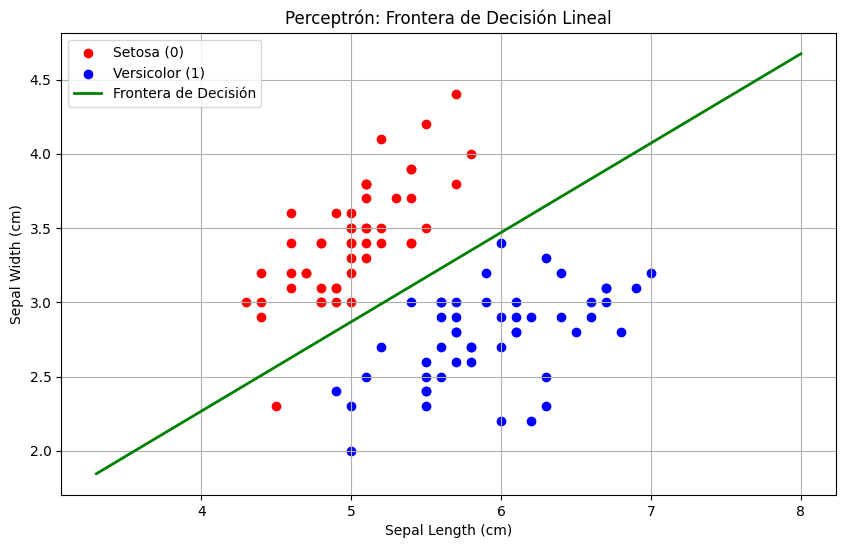

In [ ]:

plt.figure(figsize=(10, 6))
plt.scatter(x[y==0][:, 0], x[y==0][:, 1], color='red', label='Setosa (0)')
plt.scatter(x[y==1][:, 0], x[y==1][:, 1], color='blue', label='Versicolor (1)')


x1_min, x1_max = x[:, 0].min() - 1, x[:, 0].max() + 1
x1_values = np.linspace(x1_min, x1_max, 100)


w1 = p.weights[0]
w2 = p.weights[1]
b = p.bias

x2_values = -(w1 * x1_values + b) / w2

plt.plot(x1_values, x2_values, color='green', linewidth=2, label='Frontera de Decisión')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Perceptrón: Frontera de Decisión Lineal')
plt.legend()
plt.grid(True)
plt.show()

## Justifiacion del acurracy final

Nuestro Accuracy final fue del 99%, lo cual consideramos equivalente a una clasificación perfecta (1.0) para efectos prácticos. Esto sucede debido a que las clases Setosa y Versicolor son linealmente separables en el espacio de las características seleccionadas (largo y ancho del sépalo).

Este resultado valida el Teorema de Convergencia del Perceptrón. Que nos dice: si existe un hiperplano (línea recta) capaz de separar las clases perfectamente, el algoritmo de aprendizaje encontrará dicha solución en un número finito de pasos (epochs).